<a href="https://colab.research.google.com/github/adityaraghavan98/camm_hackathon/blob/k4my4r/docs/day_5_11212025/Aditya_Ferrosim_CAMM_hackaton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FerroSim: Kinetic Lattice Ferroelectric Model**

**Author: Rama Vasudevan**

This simulator evolves a ferroelectric polarization field using a time-dependent Ginzburg–Landau (TDGL) model on a 2D lattice. Each site carries a polarization order parameter:

- **Uniaxial:** scalar $p_{ij}$
- **Squareelectric:** two uncoupled components $(p_{x,ij},p_{y,ij})$
- **Tetragonal / Rhombohedral:** coupled vector $(p_{x,ij},p_{y,ij})$

The total free energy is:
$$
F = F_{\text{Landau}} + F_{\text{coupl}} + F_{\text{field}}
$$

### **1. Landau Free Energy (local double-well / multi-well potential)**

- **Uniaxial / Squareelectric:**
  $$
  F_L = \frac{\alpha_1}{2}p^2 + \frac{\alpha_2}{4}p^4
  $$
- **Tetragonal / Rhombohedral:**
  $$
  F_L = \alpha_1 (p_x^2+p_y^2)
       + \alpha_2 (p_x^4+p_y^4)
       + \alpha_3 p_x^2 p_y^2
  $$

### **2. Couping Energy**

$$
F_{\text{coupl}} = K \sum_{k,l} (p_{ij} - p_{i+k,j+l})^2
$$


### **3. Electric Field Terms**

Local field:
$$
E_{\text{loc}} = E_{\text{ext}} + E_{\text{dep}} + E_d(i,j)
$$

Depolarization field:
$$
E_{\text{dep}} = -\alpha_{\text{dep}} \langle P \rangle
\qquad
\langle P \rangle = \frac{1}{N^2}\sum_{ij} p_{ij}
$$

External field $E_{\text{ext}}(t)$ can be an arbitrary waveform.

Defect field $E_d(i,j)$ introduces random-field.

### **4. TDGL Dynamics**

Evolution follows:
$$
\frac{dp_{ij}}{dt} = -\gamma \frac{\partial F}{\partial p_{ij}}
$$

Updated explicitly:
$$
p_{ij}(t+\Delta t) = p_{ij}(t) + \Delta t\,\frac{dp_{ij}}{dt}
$$

$\gamma$ is the mobility (domain-wall damping).  
$\Delta t$ is the numerical time step.

### **5. Model Parameters**

- **Landau coefficients:** $\alpha_1, \alpha_2, \alpha_3$
- **Coupling:** $K$
- **Depolarizing coef.:** $\alpha_{\text{dep}}$
- **External field:** $E_{\text{ext}}(t)$
- **Defect field:** $E_d(i,j)$
- **Mobility:** $\gamma$
- **Time step:** $\Delta t$

### **Modes Summary**

- **Uniaxial:** scalar double-well potential.
- **Squareelectric:** two independent double wells in $x$ and $y$.
- **Tetragonal:** coupled components; minima along axes.
- **Rhombohedral:** coupled components; minima along diagonal directions.

This toy model captures ferroelectric switching, domain formation, domain wall motion, defect pinning, and polarization dynamics under applied fields.


**Default coef.** **$\alpha_1$ $\alpha_2$ $\alpha_3$**

*Uniaxial:* -1.85,	1.25, N/A

*Squareelectric:* -1.85,	1.25, N/A

*Tetragonal:* -1.6	12.2	40.0

*Rhombohedral:* -10.6	10.2	-10.0

**NOTE: The coefficients for the rhomohedral case don't appear to be very good. Need to adjust them.**





---






**Github**: https://github.com/ramav87/FerroSim/tree/rama-dev (branch: rama-dev)

In [1]:
!pip install -e git+https://github.com/ramav87/FerroSim.git@rama-dev#egg=FerroSim

Obtaining FerroSim from git+https://github.com/ramav87/FerroSim.git@rama-dev#egg=FerroSim
  Cloning https://github.com/ramav87/FerroSim.git (to revision rama-dev) to ./src/ferrosim
  Running command git clone --filter=blob:none --quiet https://github.com/ramav87/FerroSim.git /content/src/ferrosim
  Running command git checkout -b rama-dev --track origin/rama-dev
  Switched to a new branch 'rama-dev'
  Branch 'rama-dev' set up to track remote branch 'rama-dev' from 'origin'.
  Resolved https://github.com/ramav87/FerroSim.git to commit 83b79be078001e93d4d10fcab403ba2f8d688a27
  Preparing metadata (setup.py) ... done
  Running setup.py develop for FerroSim




> **Session must be restarted after ferrosim lib uploading**



In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec

import h5py
import math

from typing import Dict
from itertools import product

from ferrosim import Ferro2DSim

## Uniaxial switching

---Performing simulation---


100%|██████████| 498/498 [00:05<00:00, 95.69it/s] 


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 189.62it/s]


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 192.83it/s]


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 182.98it/s]


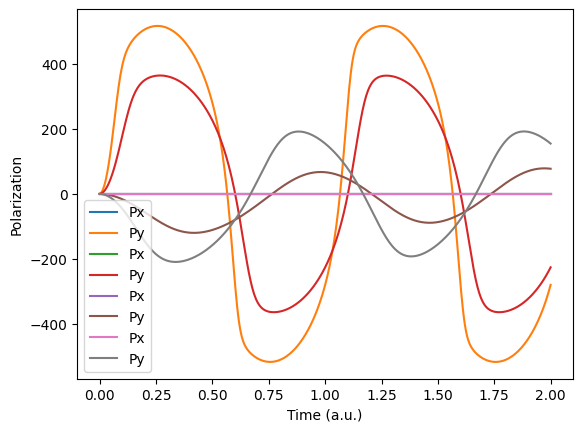

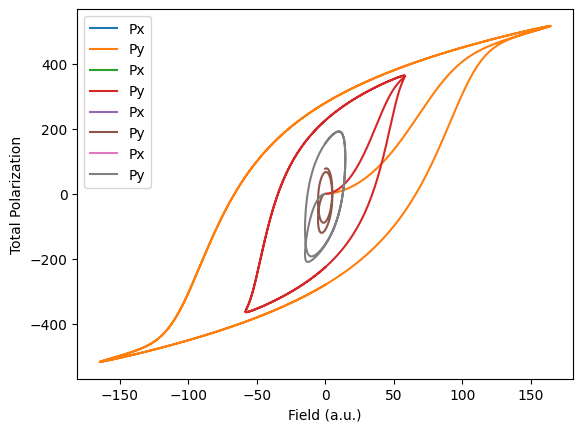

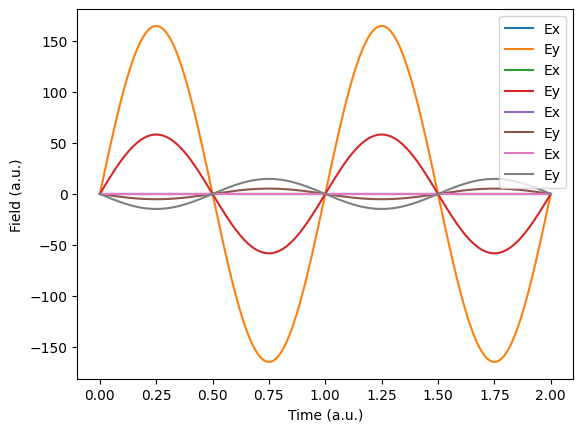

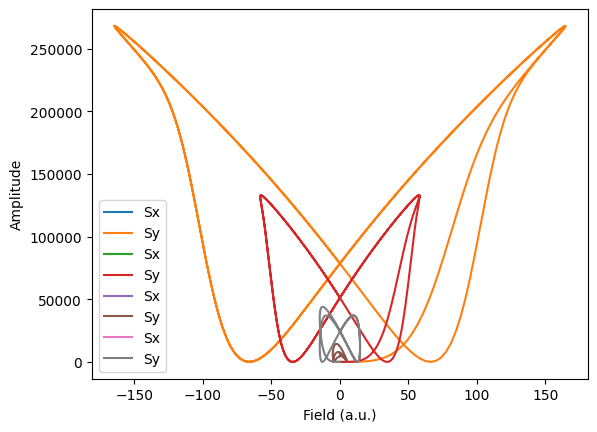

In [2]:
Pmats = []
for temp in [300, 350, 410, 420]:
  time_vec = np.linspace(0,2,500)

  #Let's now make a somewhat complicated electric field
  Evec_x = 0*np.ones(len(time_vec))
  Evec_y = 190*np.sin(2*np.pi*time_vec)
  applied_field = np.vstack((Evec_x, Evec_y)).T

  landau_parms = {'alpha1': 1.85/100 , 'alpha2':1.25 } #alpha1 is technically the temperature independent term, it gets multiplied by T diff.

  init_pmat = np.random.uniform(low = -0.2, high = 0.2, size = (10,10))*1.0E-6
  init_pmat_full = np.zeros(shape=(10,10,2))
  init_pmat_full[:,:,1] = init_pmat


  sim = Ferro2DSim(mode = 'uniaxial',
                   k = 1.0,
                   temp = temp,
                   time_vec = time_vec,
                   appliedE = applied_field,
                   initial_p = init_pmat_full,
                   landau_parms = landau_parms,
                   )
  sim.runSim()

  sim.plot_summary()
  #sim.plot_quiver()
  Pmats.append(sim.getPmat())
  del sim

(array([-600., -400., -200.,    0.,  200.,  400.,  600.]),
 [Text(0, -600.0, '−600'),
  Text(0, -400.0, '−400'),
  Text(0, -200.0, '−200'),
  Text(0, 0.0, '0'),
  Text(0, 200.0, '200'),
  Text(0, 400.0, '400'),
  Text(0, 600.0, '600')])

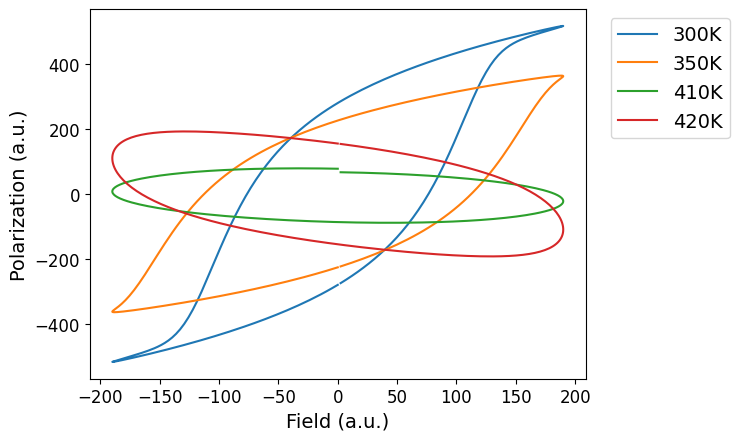

In [3]:
plt.figure()
labels = ['300K', '350K', '410K', '420K']
for ind in range(4):
  fe_loop = Pmats[ind][1,:,:,:].sum(axis=((-1,-2)))
  plt.plot(applied_field[250:,1], fe_loop[250:], label = labels[ind])
plt.legend(loc = [1.05, 0.65], fontsize = 14)

plt.xlabel('Field (a.u.)', fontsize = 14)
plt.ylabel('Polarization (a.u.)', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

## Custom field: tetragonal

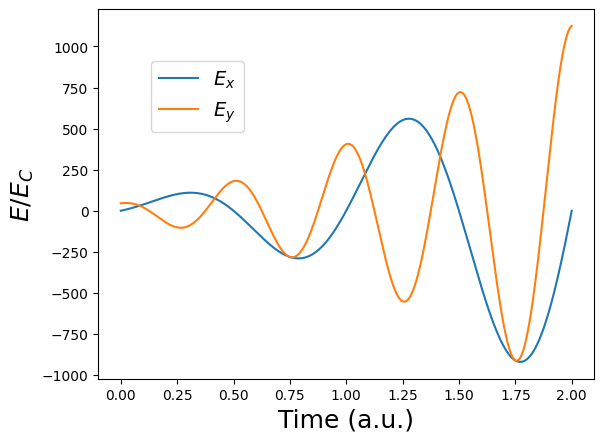

In [4]:
time_vec = np.linspace(0,2,500)

#Let's now make a somewhat complicated electric field
Evec_x = 180*((time_vec+0.5)**2)*np.sin(2*np.pi*time_vec)
Evec_y = 180*((time_vec+0.5)**2)*np.cos(4*np.pi*time_vec)

applied_field = np.vstack((Evec_x, Evec_y)).T

#Let's plot this to see what it looks like
fig, axes = plt.subplots()
axes.plot(time_vec, applied_field[:,0], label ='$E_x$')
axes.plot(time_vec, applied_field[:,1], label ='$E_y$')
axes.set_xlabel('Time (a.u.)', fontsize = 18)
axes.set_ylabel('$E/E_C$', fontsize = 18)
fig.legend(loc = [0.25, 0.70], fontsize = 14)

---Performing simulation---


100%|██████████| 498/498 [00:13<00:00, 36.28it/s]


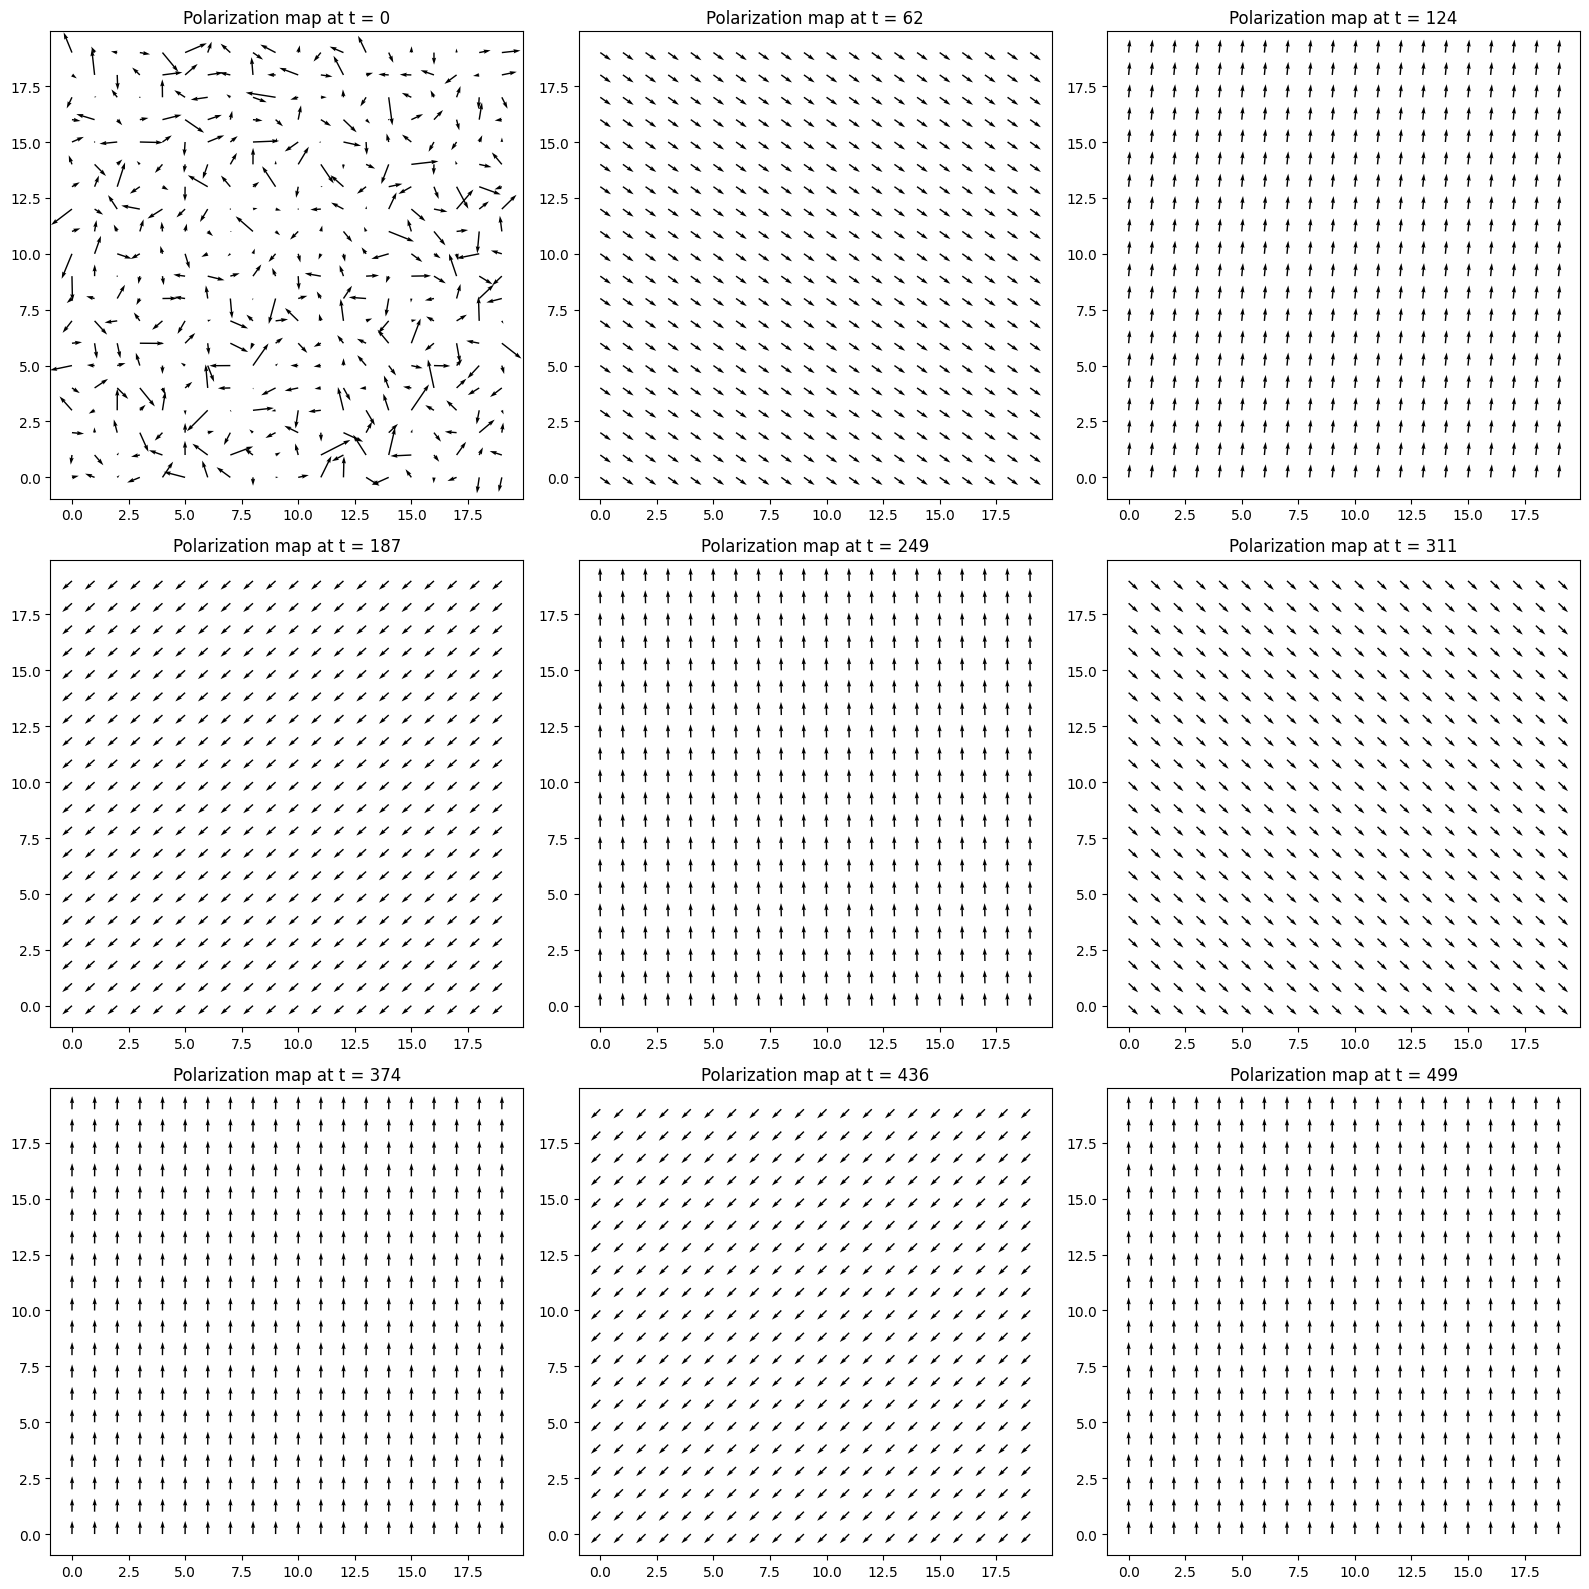

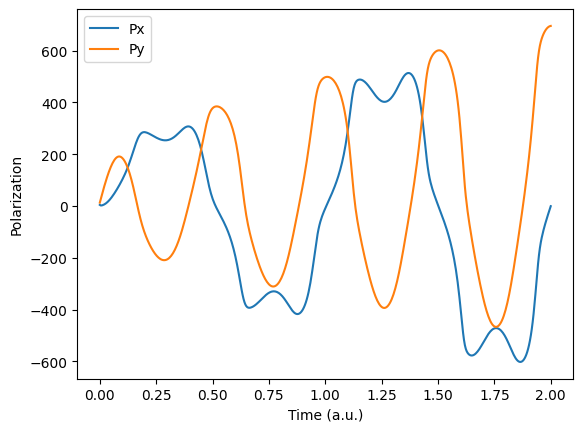

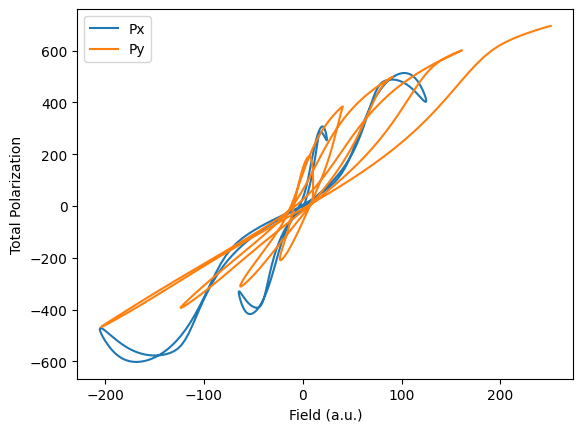

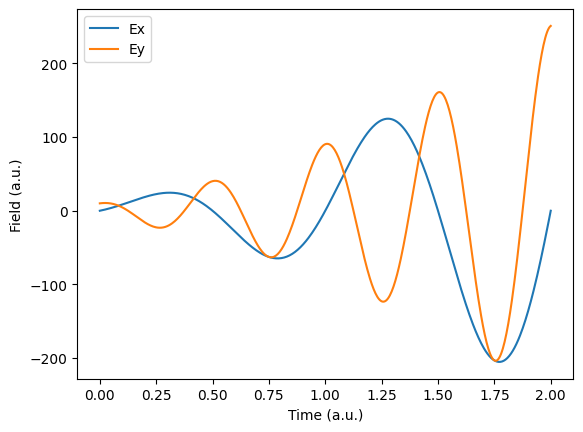

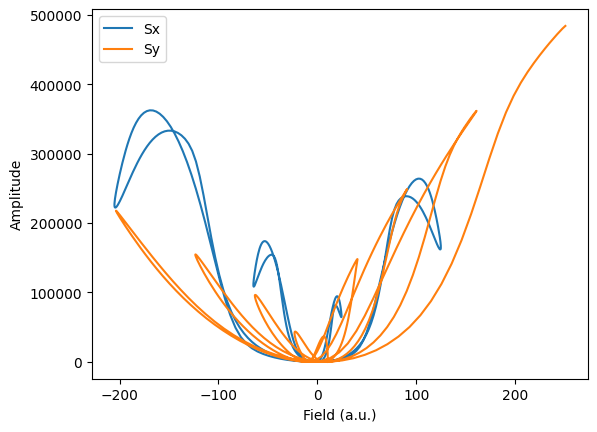

In [5]:
sim = Ferro2DSim(n=20, time_vec = time_vec, appliedE= applied_field,
                 mode = 'tetragonal', init = 'random')
sim.runSim()
sim.plot_quiver()
sim.plot_summary()

## Adding Custom Defects

We can also add defects to the simulation easily.

### Random Field Effects
Defects can interact with the lattice through field effects (no elastic considerations in this model whatsoever). The simulation expects defects to be entered in as a list of length (n x n) with each element being a tuple $(RF_x, RF_y)$. The units of the $RF_x$ and $RF_y$ are, as with the applied field, multiples of the nominal coercive field (set by the simulations alpha and beta values in the Landau expansion - that can also be changed if you so wish!).

### Random Bond Effects
We can also add defects that produce random-bond disorder: in this case, the coupling constant k is no longer uniform, but spatially dependent. So, k should now be provided as a list of size (n x n). The Default is a list of length (n x n) with all elements set to 1.0.

### Screening effects
Finally, we note that depolarization effects are considered in the model as a uniform constant multipled by the total polarization. However, we can alter this by assuming some screening (e.g., from migration of internal charges, or band bending etc.). The simulation then expects a list of length (n x n) with each element equal to the factor that multiples the total polarization. The Default is set to 0.0 at all sites.

In [6]:
n = 20 #lattice size
time_vec = np.linspace(0,4,500)

defect_list = []
for row in range(n):
    for col in range(n):
        Efx = 0.01
        Efy = 0.01
        #We place defects every fifth row and 2nd column
        if row%5==0 and col%10==0: Efy = np.random.normal(loc = 15.5, scale = 0.1)

        defect_list.append((Efx, Efy))
defect_list = np.array(defect_list)


#Let's add some random bond disorder. Here we will assume the random bond disorder
#is just a small noise term on teh existing constant value
k = [np.random.normal(loc=1.0,scale = 0.1) for ind in range(n*n)]

#Finally, let's also play with the depolarization. In this case it is going to be random.
dep_alpha = [np.random.uniform(low=0.4, high= 0.8) for ind in range(n*n)]

#Let's just have a sinusoidal field
Evec_x = 10*np.ones(len(time_vec))
Evec_y = 190*np.sin(2*np.pi*time_vec)
applied_field = np.vstack((Evec_x, Evec_y)).T

In [7]:
sim = Ferro2DSim(n=n,
                 time_vec = time_vec,
                 appliedE=applied_field,
                 defects=defect_list,
                 k=k,
                 dep_alpha = dep_alpha,
                 mode = 'tetragonal')

---Performing simulation---


100%|██████████| 498/498 [00:13<00:00, 37.03it/s]


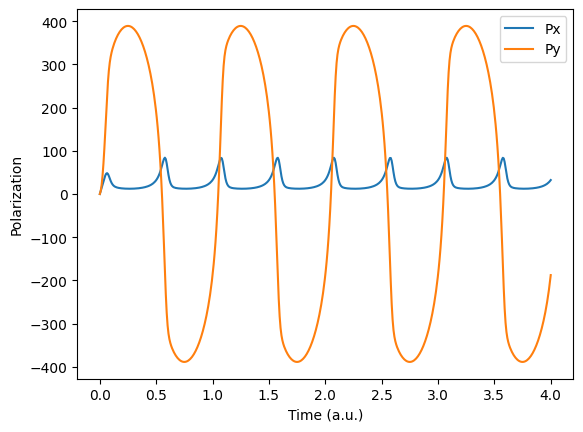

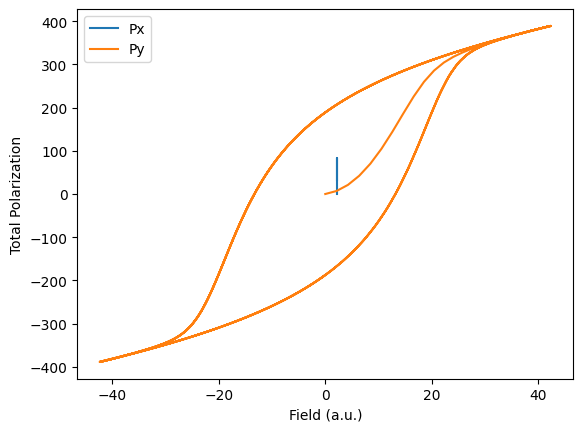

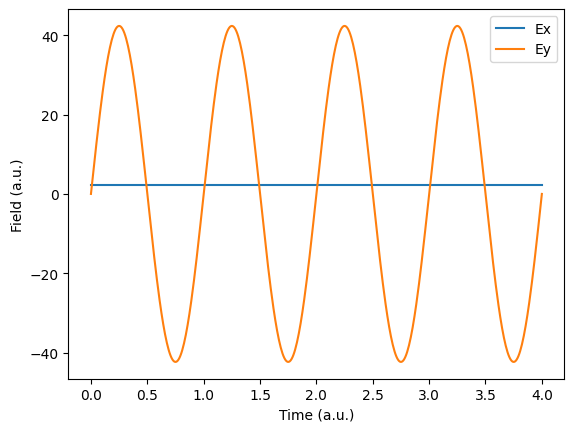

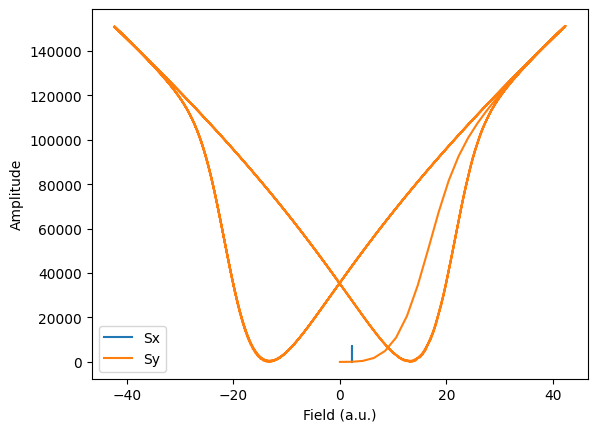

In [8]:
sim.runSim()
sim.plot_summary()

## "Domain" structures

In [9]:
def ferrosim_calc1(patch,
                  gamma = 30,
                  defect_field = (30,.01),
                  c_const = 1.1,
                  Eamp = (0, 2),
                  time_vec_length = 3000,
                  dep_alpha = 1E-9):
  #tiem vec
  time_vec = np.linspace(0,2,time_vec_length)
  flat_patch = np.array(patch.flatten())

  #defect field
  Efx, Efy = defect_field

  defect_list = np.zeros((len(flat_patch),2))#np.ones((len(flat_patch),2))*1E-6
  defect_list[flat_patch==0] = (Efx, 0)
  defect_list[flat_patch!=0] =  np.array([np.zeros(len(flat_patch[flat_patch!=0])), -flat_patch[flat_patch!=0]*Efy]).T

  #coupling constant
  k = np.zeros(len(flat_patch))
  k[flat_patch!=0] = c_const

  #applied field
  Evec_x = Eamp[0]*np.ones(len(time_vec))
  Evec_y = Eamp[1]*np.sin(2*np.pi*time_vec)
  applied_field = np.vstack((Evec_x, Evec_y)).T

  #initial P
  init_p  = np.zeros((ws,ws,2))#np.random.uniform(low = -0.2, high = 0.2, size = (ws,ws,2))*1.0E-9

  init_p[:,:,0][patch==0] = 1
  init_p[:,:,1][patch!=0] = patch[patch!=0]*.5

  sim = Ferro2DSim(n=ws,
                  time_vec = time_vec,
                  appliedE=applied_field,
                  defects=defect_list,
                  k=k,
                  dep_alpha = dep_alpha,
                  mode = 'tetragonal',
                  gamma=gamma,
                  initial_p = init_p,)

  sim.runSim();

  return (applied_field.T, sim.results['Polarization'])


def res_pattern(k, stripe_frequency, phase, size=(12,12)):
  c_domain_pattern = c_domain(k, size=size)
  a_domain_pattern = striped_pattern(stripe_frequency, phase, size=size)
  res = (c_domain_pattern*2-1) * (~a_domain_pattern)
  return res, c_domain_pattern, a_domain_pattern

def c_domain(k, size=(12,12)):
  a_pattern = np.array([[1 if (i-k < j) else 0 for j in range(size[0])] for i in range(size[1])])
  return a_pattern.astype(bool)

def striped_pattern(stripe_frequency, phase, size=(12,12), stripe_width=2):
  pattern = np.zeros(size, dtype=int)

  for i in range(size[0]):
      for j in range(size[1]):
          if ((i + j) // stripe_width + phase) % stripe_frequency == 0:
              pattern[i, j] = 1

  return pattern.astype(bool)

def shoelace_formula(x, y):
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

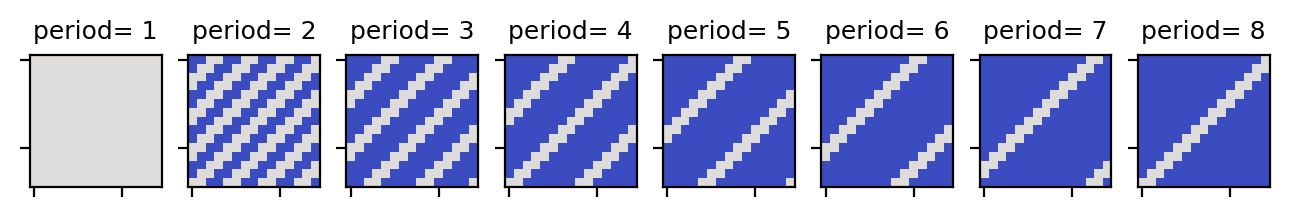

In [10]:
ws = 15

sf = np.arange(1,9)

patterns = []
for f in sf:
  patterns.append(res_pattern(-15, f, 1, size=(ws,ws)))


fig, ax = plt.subplots(1, len(patterns), figsize=(len(patterns), 1.2), dpi=200)

for i,p in enumerate(patterns):
  ax[i].imshow(p[0], vmin=-1, vmax=1, cmap='coolwarm')
  ax[i].tick_params(labelleft=False, labelbottom=False)
  ax[i].set_title(f"period= {sf[i]}", fontsize=9)

In [11]:
pol_ar = []

for i,p in enumerate(patterns):
  v, pol = ferrosim_calc1(p[0],
                  gamma = 30, #kinetic coefficient in Landau-Khalatnikov equation (~wall mobility)
                  defect_field = (30,.1),
                  c_const = 0, #coupling constant
                  Eamp = (0, 2), #amplitude of the applied voltage
                  time_vec_length = 2000, #number of the time steps, we always apply 2 sin period
                  dep_alpha = .3 #depolarization constant
                          )
  pol_ar.append(pol)

pol_ar = np.array(pol_ar) #polarization hysteresis loops

---Performing simulation---


100%|██████████| 1998/1998 [00:32<00:00, 62.02it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:30<00:00, 66.39it/s]


---Performing simulation---


...

100%|██████████| 1998/1998 [00:30<00:00, 65.88it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:29<00:00, 67.55it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:29<00:00, 67.55it/s]


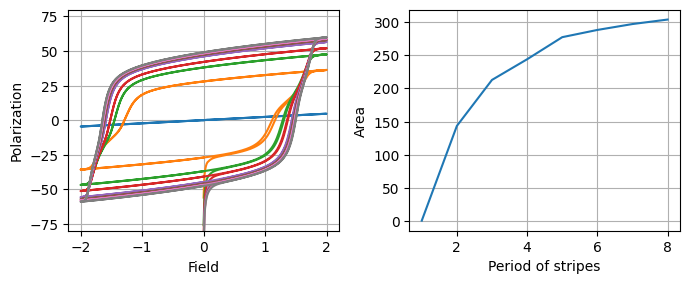

In [12]:
loop_area = np.array([])
fig, ax = plt.subplots(1,2, figsize=(7,3))

for pp in pol_ar:
  loop_area = np.append(loop_area, float(shoelace_formula(v[1,-1000:], pp[1, -1000:]))) #
  ax[0].plot(v[1], pp[1])

ax[0].grid()
ax[0].set_ylabel("Polarization")
ax[0].set_xlabel("Field")
ax[0].set_ylim(-80,80)

ax[1].plot(sf, loop_area)
ax[1].grid()
ax[1].set_ylabel('Area')
ax[1].set_xlabel('Period of stripes')

plt.tight_layout()

#  Attempt: Using CMA-ES to Explore “Material Space”

In this part of the notebook, I’m trying out whether an **Covariance Matrix Adaptation Evolution-Strategy approach (CMA-ES)** can help navigate the Landau parameter space more efficiently than brute-force sweeps or standard GP-BO.

The idea is to treat the Landau coefficients and temperature as a **material design vector**
$
\theta = (\alpha_1, \alpha_2, T),
$
run the ferroelectric simulator for each candidate θ, extract a property of interest (in my case: **hysteresis loop area**), and let CMA-ES iteratively adjust its sampling distribution based on what performs well.

Instead of searching a huge grid, CMA-ES maintains a **Gaussian over the parameters** (mean + covariance) and updates it each generation based on the top-scoring samples. The covariance adaptation should, in theory, let the search automatically discover which directions in parameter space matter (or are correlated) for switching behavior.

This is mostly an experiment to see:

* whether CMA-ES finds high-area hysteresis loops in **far fewer simulations**,
* whether it reveals any **low-dimensional structure or correlations** in the parameters,


Will this evolutionary search could be useful for **accelerating materials discovery** in more complex or higher-dimensional models??





##Test

In [33]:
def simulate_and_score(theta,
                       n=10,
                       time_vec_length=500,
                       field_amp=190.0,
                       verbose=False):
    """
    theta = [alpha1, alpha2, temp]
    Returns:
        fitness (scalar): |loop area|
        E (1D array), P (1D array)
    """
    alpha1, alpha2, temp = theta

    # Time + sinusoidal field
    time_vec = np.linspace(0, 2, time_vec_length)
    Evec_x = 0 * np.ones_like(time_vec)
    Evec_y = field_amp * np.sin(2 * np.pi * time_vec)
    applied_field = np.vstack((Evec_x, Evec_y)).T

    landau_parms = {"alpha1": alpha1, "alpha2": alpha2}

    # Initial P (Py)
    init_pmat = np.random.uniform(low=-0.2, high=0.2, size=(n, n)) * 1.0e-6
    init_pmat_full = np.zeros((n, n, 2))
    init_pmat_full[:, :, 1] = init_pmat

    try:
        sim = Ferro2DSim(
            mode="uniaxial",
            k=1.0,
            temp=temp,
            time_vec=time_vec,
            appliedE=applied_field,
            initial_p=init_pmat_full,
            landau_parms=landau_parms,
        )
        sim.runSim()
        Pmat = sim.getPmat()  # (2, time, n, n)

        Py_t = Pmat[1].sum(axis=(-1, -2))
        Ey_t = applied_field[:, 1]

        area = abs(shoelace_formula(Ey_t, Py_t))

        if verbose:
            print(f"theta={theta} → area={area:.3f}")

        return area, Ey_t, Py_t

    except Exception as e:
        print("Simulation failed for theta =", theta, "error:", repr(e))
        return 0.0, None, None


In [48]:
def objective_wrapper(theta):
    fitness, _, _ = simulate_and_score(
        theta,
        n=10,
        time_vec_length=500,
    )
    return fitness  # IMPORTANT: scalar only


In [49]:
# === Minimal CMA-ES-style evolution strategy ===
import numpy as np

def cma_es_optimize(
    objective_fn,
    x0,
    bounds,
    sigma0=0.1,
    pop_size=16,
    n_generations=25,
    elite_frac=0.3,
    verbose=True,
):
    """
    A simple CMA-ES-style optimizer for continuous parameters.

    Args:
        objective_fn(theta) -> (fitness, E, P)
        x0       : initial mean (1D array)
        bounds   : array of shape (d, 2) with [min, max] for each dim
        sigma0   : initial overall step size (fraction of range)
        pop_size : number of samples per generation
        n_generations : number of iterations
        elite_frac    : fraction of best samples to use for updating

    Returns:
        history: dict with keys:
            'mean_list', 'best_theta', 'best_fitness', 'fitness_trace'
    """
    x0 = np.array(x0, dtype=float)
    d = len(x0)
    bounds = np.array(bounds, dtype=float)

    ranges = bounds[:, 1] - bounds[:, 0]
    cov = (sigma0 * ranges)**2 * np.eye(d)
    mean = x0.copy()

    n_elite = max(2, int(pop_size * elite_frac))

    ranks = np.arange(1, n_elite + 1)
    weights = np.log(n_elite + 0.5) - np.log(ranks)
    weights /= weights.sum()

    best_theta = None
    best_fitness = -np.inf
    fitness_trace = []
    mean_list = [mean.copy()]
    cov_list = [cov.copy()]     # <--- NEW: store covariance

    for gen in range(n_generations):
        thetas = np.random.multivariate_normal(mean, cov, size=pop_size)
        thetas = np.clip(thetas, bounds[:, 0], bounds[:, 1])

        fit = np.zeros(pop_size)
        for i in range(pop_size):
            fit[i] = objective_fn(thetas[i])

        gen_best_idx = np.argmax(fit)
        gen_best_f = fit[gen_best_idx]
        gen_best_theta = thetas[gen_best_idx].copy()

        if gen_best_f > best_fitness:
            best_fitness = gen_best_f
            best_theta = gen_best_theta.copy()

        fitness_trace.append(best_fitness)

        if verbose:
            print(f"[Gen {gen+1:02d}] best in gen = {gen_best_f:.3f}, global best = {best_fitness:.3f}")

        elite_idx = np.argsort(fit)[-n_elite:]
        elites = thetas[elite_idx]

        new_mean = np.sum(weights[:, None] * elites, axis=0)

        centered = elites - new_mean
        cov_elite = np.zeros((d, d))
        for w, c in zip(weights, centered):
            cov_elite += w * np.outer(c, c)

        c_cov = 0.3
        cov = (1 - c_cov) * cov + c_cov * cov_elite

        mean = new_mean
        mean_list.append(mean.copy())
        cov_list.append(cov.copy())   # <--- keep track

    history = {
        "mean_list": np.array(mean_list),
        "cov_list": np.array(cov_list),
        "best_theta": best_theta,
        "best_fitness": best_fitness,
        "fitness_trace": np.array(fitness_trace),
    }
    return history

In [50]:
history_short = cma_es_optimize(
    objective_fn=objective_wrapper,
    x0=np.array([1.85/100, 1.25, 350.0]),   # known good point
    bounds = np.array([
    [0.01,  0.035],   # alpha1 (the first Landau coefficient)
    [0.7,   1.8],     # alpha2 (the second Landau coefficient)
    [320.,  400.],    # T (temperature in Kelvin)
    ]),
    sigma0=0.08, # You can think of σ as the radius of the search cloud; Large σ → big jumps → exploratory behavior ; Small σ → fine-tuning / local search
    pop_size=8,
    n_generations=8,     # smaller number of evaluations
    elite_frac=0.5,
    verbose=True,
)

print("\n=== Short CMA-ES run finished ===")
print("Best theta:", history_short["best_theta"])
print("Best loop area:", history_short["best_fitness"])


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 182.56it/s]


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 184.37it/s]


---Performing simulation---


...

---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 182.36it/s]


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 167.99it/s]

[Gen 08] best in gen = 219985.645, global best = 222544.042

=== Short CMA-ES run finished ===
Best theta: [1.88618333e-02 1.06908108e+00 3.49080575e+02]
Best loop area: 222544.04246916063


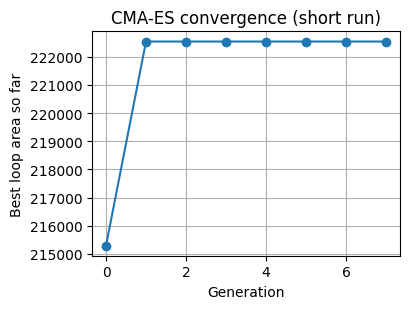

In [51]:
# Plot how the best fitness evolves during the short CMA-ES run

plt.figure(figsize=(4.2, 3.2))
plt.plot(history_short["fitness_trace"], marker='o')
plt.xlabel("Generation")
plt.ylabel("Best loop area so far")
plt.title("CMA-ES convergence (short run)")
plt.grid(True)
plt.tight_layout()
plt.show()


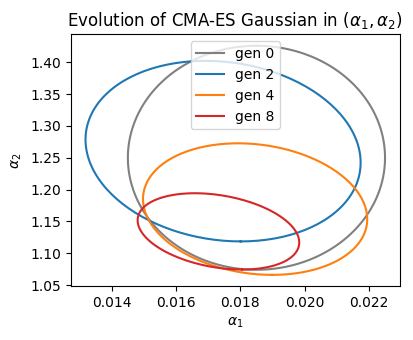

In [52]:
import matplotlib.pyplot as plt

def plot_gaussian_ellipse(mean, cov, n_std=2.0, **kwargs):
    """
    Draw an n_std ellipse for the 2D Gaussian defined by mean[0:2], cov[0:2,0:2].
    """
    from numpy.linalg import eig

    m = mean[:2]
    C = cov[:2, :2]

    vals, vecs = eig(C)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.linspace(0, 2*np.pi, 200)
    # radii = n_std * sqrt(eigenvalues)
    width, height = n_std * np.sqrt(vals)
    ellipse = np.stack([width*np.cos(theta), height*np.sin(theta)], axis=0)
    # rotate
    ellipse = vecs @ ellipse
    # shift
    ellipse = ellipse + m[:, None]

    plt.plot(ellipse[0], ellipse[1], **kwargs)

# Example: visualize a few generations of the short run
means = history_short["mean_list"]
covs  = history_short["cov_list"]

plt.figure(figsize=(4.2, 3.5))

# plot ellipses for selected generations
gens_to_show = [0, 2, 4, len(means)-1]   # first, mid, last
colors = ['gray', 'tab:blue', 'tab:orange', 'tab:red']

for idx, c in zip(gens_to_show, colors):
    plot_gaussian_ellipse(means[idx], covs[idx], n_std=2.0, color=c, label=f"gen {idx}")

plt.xlabel(r"$\alpha_1$")
plt.ylabel(r"$\alpha_2$")
plt.title("Evolution of CMA-ES Gaussian in $(\\alpha_1, \\alpha_2)$")
plt.legend()
plt.tight_layout()
plt.show()


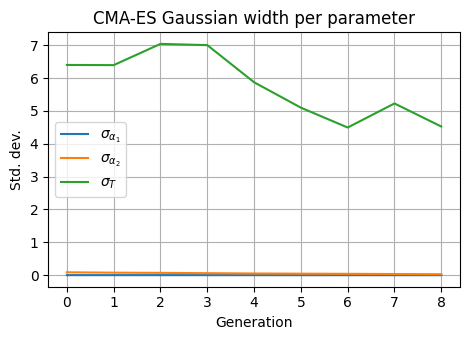

In [53]:
means = history_short["mean_list"]
covs  = history_short["cov_list"]
gens  = np.arange(len(means))

std_alpha1 = np.sqrt(covs[:, 0, 0])
std_alpha2 = np.sqrt(covs[:, 1, 1])
std_T      = np.sqrt(covs[:, 2, 2])

plt.figure(figsize=(4.8, 3.5))
plt.plot(gens, std_alpha1, label=r"$\sigma_{\alpha_1}$")
plt.plot(gens, std_alpha2, label=r"$\sigma_{\alpha_2}$")
plt.plot(gens, std_T,      label=r"$\sigma_{T}$")
plt.xlabel("Generation")
plt.ylabel("Std. dev.")
plt.title("CMA-ES Gaussian width per parameter")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


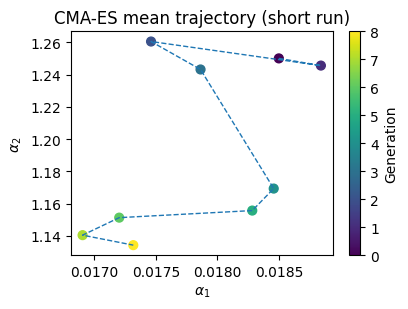

In [54]:
means = history_short["mean_list"]
gens  = np.arange(len(means))

plt.figure(figsize=(4.2, 3.2))
sc = plt.scatter(means[:, 0], means[:, 1], c=gens, cmap='viridis', s=40)
plt.plot(means[:, 0], means[:, 1], '--', linewidth=1)
plt.xlabel(r"$\alpha_1$")
plt.ylabel(r"$\alpha_2$")
plt.title("CMA-ES mean trajectory (short run)")
plt.colorbar(sc, label="Generation")
plt.tight_layout()
plt.show()


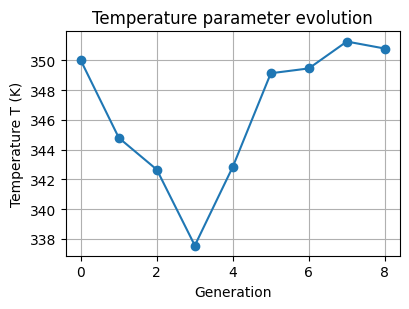

In [55]:
plt.figure(figsize=(4.2, 3.2))
plt.plot(gens, means[:, 2], marker='o')
plt.xlabel("Generation")
plt.ylabel("Temperature T (K)")
plt.title("Temperature parameter evolution")
plt.grid(True)
plt.tight_layout()
plt.show()


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 182.33it/s]


theta=[1.88618333e-02 1.06908108e+00 3.49080575e+02] → area=222544.042


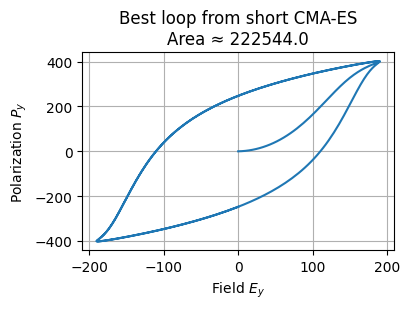

In [56]:
best_theta = history_short["best_theta"]

best_area, E_best, P_best = simulate_and_score(
    best_theta,
    n=10,
    time_vec_length=500,
    verbose=True
)

plt.figure(figsize=(4.2, 3.2))
plt.plot(E_best, P_best, lw=1.5)
plt.xlabel("Field $E_y$")
plt.ylabel("Polarization $P_y$")
plt.title(f"Best loop from short CMA-ES\nArea ≈ {best_area:.1f}")
plt.grid(True)
plt.tight_layout()
plt.show()


## Full

In [57]:
history_long = cma_es_optimize(
    objective_fn=objective_wrapper,
    x0=np.array([1.85/100, 1.25, 350.0]),
    bounds=np.array([
        [0.010, 0.040],
        [0.6,   2.2],
        [300.,  430.],
    ]),
    sigma0=0.08,
    pop_size=12,
    n_generations=20,    # 240 total simulations
    elite_frac=0.4,
    verbose=True,
)

print("\n=== Long CMA-ES run finished ===")
print("Best theta:", history_long["best_theta"])
print("Best loop area:", history_long["best_fitness"])


---Performing simulation---


100%|██████████| 498/498 [00:04<00:00, 101.63it/s]


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 186.90it/s]


---Performing simulation---


...

---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 183.43it/s]


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 186.18it/s]

[Gen 20] best in gen = 274893.009, global best = 275713.071

=== Long CMA-ES run finished ===
Best theta: [2.23739795e-02 7.18424119e-01 3.64209270e+02]
Best loop area: 275713.07132344134


In [58]:
import numpy as np
import matplotlib.pyplot as plt

# ------------- Helpers -------------

def plot_gaussian_ellipse_2d(mean, cov, idx_x, idx_y, n_std=2.0, **kwargs):
    """
    Draw an n_std ellipse for the 2D marginal of a multivariate Gaussian.

    mean: 1D array of shape (d,)
    cov:  2D array of shape (d, d)
    idx_x, idx_y: indices of the parameters to plot (e.g., 0 and 2 for alpha1 vs T)
    """
    from numpy.linalg import eig

    m = np.array([mean[idx_x], mean[idx_y]])
    C = np.array([[cov[idx_x, idx_x], cov[idx_x, idx_y]],
                  [cov[idx_y, idx_x], cov[idx_y, idx_y]]])

    # If covariance is near-singular, skip plotting
    if not np.all(np.isfinite(C)) or np.any(np.diag(C) <= 0):
        return

    vals, vecs = eig(C)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.linspace(0, 2*np.pi, 200)
    width, height = n_std * np.sqrt(np.maximum(vals, 0))
    ellipse = np.stack([width*np.cos(theta), height*np.sin(theta)], axis=0)
    ellipse = vecs @ ellipse
    ellipse = ellipse + m[:, None]

    plt.plot(ellipse[0], ellipse[1], **kwargs)


def extract_history_arrays(history):
    """
    Convenience: pull out arrays from history dict.
    """
    means = np.array(history["mean_list"])      # shape: (G+1, d)
    covs  = np.array(history["cov_list"])       # shape: (G+1, d, d)
    fit   = np.array(history["fitness_trace"])  # shape: (G,)
    return means, covs, fit


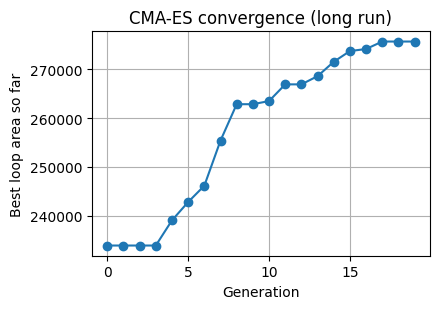

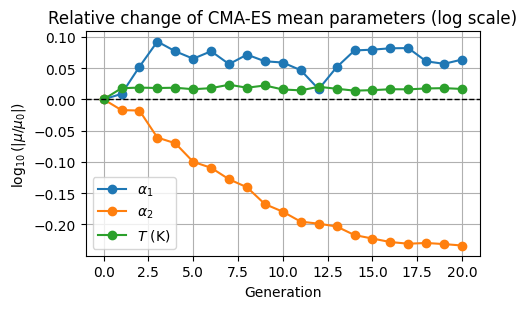

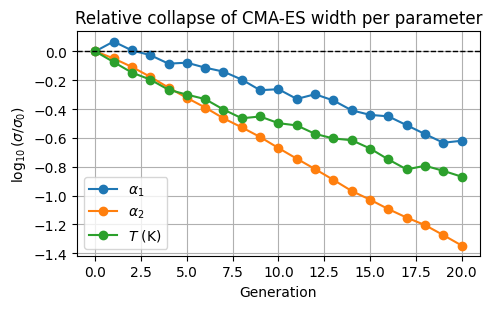

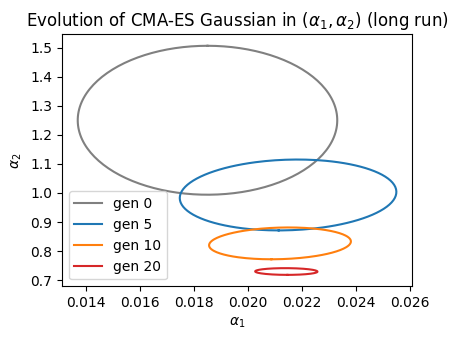

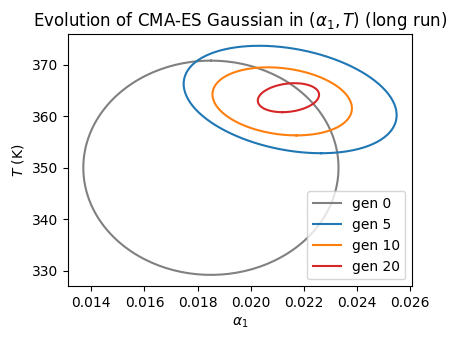

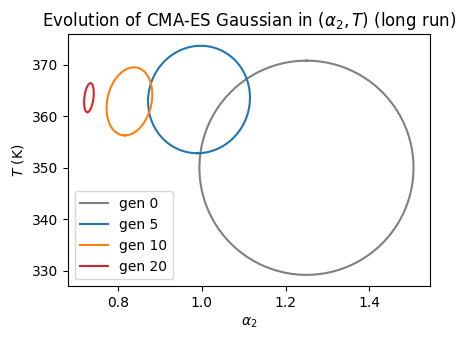

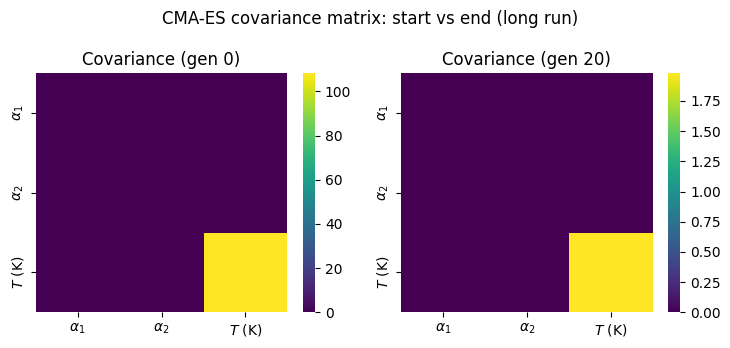

In [65]:
# Use the long run history
means_long, covs_long, fit_long = extract_history_arrays(history_long)
gens_long = np.arange(len(means_long))  # G+1 entries (gen 0..G)

# Parameter labels (for plotting)
param_names = [r"$\alpha_1$", r"$\alpha_2$", r"$T$ (K)"]

# ---------------- 1) Convergence curve ----------------
plt.figure(figsize=(4.5, 3.2))
plt.plot(fit_long, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best loop area so far")
plt.title("CMA-ES convergence (long run)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------- 2) Parameter means vs generation ----------------
# means_long: (G+1, 3) array from your history
means_long = np.array(history_long["mean_list"])
G = means_long.shape[0]

# Normalize by initial mean for each parameter
eps = 1e-12
means_norm = means_long / (means_long[0] + eps)   # shape (G+1, 3)

plt.figure(figsize=(5.0, 3.2))
for i in range(means_norm.shape[1]):
    plt.plot(
        gens_long,
        np.log10(np.abs(means_norm[:, i]) + eps),
        marker='o',
        label=param_names[i]
    )

plt.xlabel("Generation")
plt.ylabel(r"$\log_{10}(|\mu / \mu_0|)$")
plt.title("Relative change of CMA-ES mean parameters (log scale)")
plt.axhline(0.0, color='k', linestyle='--', linewidth=1)   # starting level
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()


# ---------------- 3) Parameter std dev vs generation ----------------
stds_long = np.sqrt(np.maximum(np.diagonal(covs_long, axis1=1, axis2=2), 0))  # shape: (G+1, d)
# stds_long: (G+1, 3) from your existing code
stds_long = np.sqrt(
    np.maximum(np.diagonal(covs_long, axis1=1, axis2=2), 0)
)  # shape: (G+1, d)

# Normalize by initial value for each parameter
stds_norm = stds_long / stds_long[0]  # each column: std / std_at_gen0

eps = 1e-12
plt.figure(figsize=(5.0, 3.2))
for i in range(stds_norm.shape[1]):
    plt.plot(
        gens_long,
        np.log10(stds_norm[:, i] + eps),
        marker='o',
        label=param_names[i]
    )

plt.xlabel("Generation")
plt.ylabel(r"$\log_{10}(\sigma / \sigma_0)$")
plt.title("Relative collapse of CMA-ES width per parameter")
plt.axhline(0.0, color='k', linestyle='--', linewidth=1)  # starting level
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()



# ---------------- 4) Gaussian ellipses in (alpha1, alpha2) ----------------
plt.figure(figsize=(4.5, 3.5))

G = len(means_long) - 1
gens_to_show = [0, max(1, G//4), max(1, G//2), G]
colors = ['gray', 'tab:blue', 'tab:orange', 'tab:red']

for idx, c in zip(gens_to_show, colors):
    plot_gaussian_ellipse_2d(
        means_long[idx], covs_long[idx],
        idx_x=0, idx_y=1,      # alpha1 vs alpha2
        n_std=2.0,
        color=c,
        label=f"gen {idx}"
    )

plt.xlabel(r"$\alpha_1$")
plt.ylabel(r"$\alpha_2$")
plt.title("Evolution of CMA-ES Gaussian in $(\\alpha_1, \\alpha_2)$ (long run)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------- 5) Gaussian ellipses in (alpha1, T) ----------------
plt.figure(figsize=(4.5, 3.5))

for idx, c in zip(gens_to_show, colors):
    plot_gaussian_ellipse_2d(
        means_long[idx], covs_long[idx],
        idx_x=0, idx_y=2,      # alpha1 vs T
        n_std=2.0,
        color=c,
        label=f"gen {idx}"
    )

plt.xlabel(r"$\alpha_1$")
plt.ylabel(r"$T$ (K)")
plt.title("Evolution of CMA-ES Gaussian in $(\\alpha_1, T)$ (long run)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------- 6) Gaussian ellipses in (alpha2, T) ----------------
plt.figure(figsize=(4.5, 3.5))

for idx, c in zip(gens_to_show, colors):
    plot_gaussian_ellipse_2d(
        means_long[idx], covs_long[idx],
        idx_x=1, idx_y=2,      # alpha2 vs T
        n_std=2.0,
        color=c,
        label=f"gen {idx}"
    )

plt.xlabel(r"$\alpha_2$")
plt.ylabel(r"$T$ (K)")
plt.title("Evolution of CMA-ES Gaussian in $(\\alpha_2, T)$ (long run)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------- 7) Covariance heatmaps: first vs last generation ----------------
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))

sns.heatmap(covs_long[0], ax=axes[0], cmap="viridis", annot=False,
            xticklabels=param_names, yticklabels=param_names)
axes[0].set_title("Covariance (gen 0)")

sns.heatmap(covs_long[-1], ax=axes[1], cmap="viridis", annot=False,
            xticklabels=param_names, yticklabels=param_names)
axes[1].set_title(f"Covariance (gen {G})")

plt.suptitle("CMA-ES covariance matrix: start vs end (long run)")
plt.tight_layout()
plt.show()


---Performing simulation---


100%|██████████| 498/498 [00:03<00:00, 130.95it/s]


theta=[1.85e-02 1.25e+00 3.50e+02] → area=206619.987
---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 187.07it/s]


theta=[2.14162375e-02 7.29969729e-01 3.63606333e+02] → area=273929.236


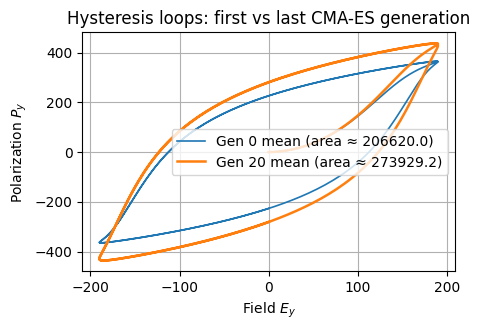

In [61]:
# Hysteresis loops at first vs last generation (using CMA-ES means)

means_long, covs_long, fit_long = extract_history_arrays(history_long)
G = len(means_long) - 1  # last generation index

theta_first = means_long[0]
theta_last  = means_long[-1]

area_first, E_first, P_first = simulate_and_score(
    theta_first,
    n=10,
    time_vec_length=500,
    verbose=True
)

area_last, E_last, P_last = simulate_and_score(
    theta_last,
    n=10,
    time_vec_length=500,
    verbose=True
)

plt.figure(figsize=(4.8, 3.4))
plt.plot(E_first, P_first, lw=1.2, label=f"Gen 0 mean (area ≈ {area_first:.1f})")
plt.plot(E_last,  P_last,  lw=1.8, label=f"Gen {G} mean (area ≈ {area_last:.1f})")

plt.xlabel("Field $E_y$")
plt.ylabel("Polarization $P_y$")
plt.title("Hysteresis loops: first vs last CMA-ES generation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# **Next Steps: Going Beyond Loop Area**

So far, we optimized only the **loop area**.
The natural extension is to optimize **loop shape**.

### **1. Add shape-based metrics**

### **2. Build a “loop shape phase diagram”**

Use CMA-ES or random sampling to classify loops (thin, fat, shifted, asymmetric) and map where they occur in ($\alpha_1, \alpha_2, T$).

### **3. Add more parameters**